# Concept figure: what the dark-microhalo astrometric signal looks like

Produces ten typical draws, **`figs/concept_0.pdf`** ... **`figs/concept_9.pdf`**;
**`figs/concept.pdf`** is a copy of the one shown as Fig. 2 of the paper.

Simulates a Gaussian realization of the stochastic image-pair separation
$\delta\theta^\mathrm{A,B}(t)$ for the galaxy lens B1422+231, drawn from the
*analytic* power spectral density $\widetilde{C}_{pq}(\omega)$ of Eq. (C)
(subhalo mass $M_\mathrm{L} = 10^{-4}\,M_\odot$, scale density
$\rho_s = 10\,M_\odot\,\mathrm{pc^{-3}}$, $f_\mathrm{sub} = 0.5$ --- the same
fiducial as the `CtildeA.pdf` panel of `sensitivity.ipynb`), samples it with the
fiducial EPIC campaign ($\tau = 10\,\mathrm{yr},~N = 300$,
$\sigma_{\delta\theta} = 0.1\,\mathrm{\mu as}$), and shows:

1. the **sky-plane trajectory** of the image-pair separation after subtracting the
   best-fit linear relative motion --- the random walk induced by dark microhalos,
   resolved by half-year (15-epoch) averages of the data;
2. the **dominant component versus time** with the best-fit quadratic overlaid:
   when individual halo crossings are not time-resolved, the random walk shows up
   as an anomalous differential acceleration --- the Eq. (observable_2) statistic.

Only the galaxy lens is illustrated here; the cluster-lens analogue of the
underlying PSD and acceleration response is in Part II of `sensitivity.ipynb`.

*Runtime: a few seconds.*

## Setup

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from params_B1422_231 import *

colors = sns.color_palette(xgfs_fancy6)

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas


## Fiducial configuration

Macro-lens quantities ($B^\mathrm{I} = $ `inv_jacobian_fit`, $\kappa^\mathrm{I}$)
come from `macro_lens.ipynb`. The image--subhalo sweep rate uses the bulk lens
velocity magnified by $B^\mathrm{I}$, with the subhalos' internal motion added
*unmagnified* in quadrature (see `params_B1422_231.py`).

In [2]:
res = np.load('macro_lens_results.npz')
inv_jacobian_fit = res['inv_jacobian_fit']; kappa_fit = res['kappa_fit']
v_lens = v_lens_fid   # bulk fiducial, |v_L| ~ 865 km/s (see params_B1422_231)
vec_mu = mu_rel(np.zeros(2)*km/second, v_lens, np.zeros(2)*km/second,
                z_lens, z_source, d_lens, d_source, d_lens_source)
vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu, axes=1)
# sweep rate d/dt[theta^I - theta_L] = B^I mu - mu_L: the bulk term is magnified by B^I,
# the subhalos' own orbital motion mu_L is not (footnote to Sec. II C)
mu_tilde = np.sqrt(np.linalg.norm(vec_mu_tilde, axis=1)**2 + mu_L_int**2)
zeta = np.arctan2(vec_mu_tilde[:, 1], vec_mu_tilde[:, 0])

tau = 10 * year
N_obs = 300
sigma_delta_theta = 0.1 * muas
f_sub = 0.5
M_L = 1e-4 * M_Solar
rho_s = 10 * M_Solar / pc**3
r_L = (M_L/(rho_s*(4*np.pi*np.exp(1/2))))**(1/3)   # M_L = 4 pi sqrt(e) rho_s r_L^3
gamma_L = r_L / d_lens
theta_E_L = theta_E(M_L, d_lens, d_source, d_lens_source)

print('mu_tilde = %s muas/yr' % np.round(mu_tilde/muasy, 3))
print('gamma_L  = %.3g muas,  theta_E_L = %.3g muas' % (gamma_L/muas, theta_E_L/muas))

mu_tilde = [0.987 1.384 0.504 0.065] muas/yr
gamma_L  = 1.62 muas,  theta_E_L = 0.0256 muas


## Differential PSD of the A,B image pair

$\widetilde{C}^\mathrm{A,B}_{pq} = \widetilde{C}^\mathrm{A}_{pq} + \widetilde{C}^\mathrm{B}_{pq}$
(the two images see statistically independent subhalo fields), each macro-lensed
by its own $B^\mathrm{I}$.

In [3]:
vec_omega = np.logspace(np.log10(2*np.pi/(20*tau)), np.log10(np.pi*N_obs/tau), 4000)
arr_C = np.zeros((2, 2, len(vec_omega)))
for i in [0, 1]:   # images A, B
    C_ij = f_sub*kappa_fit[i]*theta_E_L**2/vec_omega * C_ij_integral(gamma_L/mu_tilde[i]*vec_omega, zeta[i])
    arr_C += np.einsum('qj,pjm->pqm', inv_jacobian_fit[i], np.einsum('pi,ijm->pjm', inv_jacobian_fit[i], C_ij))

## Gaussian realization and the fitted acceleration

Each frequency bin contributes an independent 2D Gaussian with covariance
$\widetilde{C}_{pq}(\omega_n)\,\Delta\omega_n/\pi$; summing cosine and sine
components gives a time series with the prescribed spectrum. We then remove the
best-fit constant and linear motion (degenerate with the macro-lens model) and
compare the fitted quadratic to the rms expectation from the same smeared
$\omega^4$ moment of the PSD that defines Eq. (observable_2).

In [4]:
t_obs = np.linspace(-tau/2, tau/2, N_obs)
d_omega = np.gradient(vec_omega)

def realization(seed):
    rng = np.random.default_rng(seed)
    theta_t = np.zeros((2, N_obs))
    for n in range(len(vec_omega)):
        Cn = arr_C[:, :, n] * d_omega[n] / np.pi          # per-mode 2x2 covariance
        L = np.linalg.cholesky(Cn + 1e-40*np.eye(2))
        a = L @ rng.standard_normal(2); b = L @ rng.standard_normal(2)
        theta_t += np.outer(a, np.cos(vec_omega[n]*t_obs)) + np.outer(b, np.sin(vec_omega[n]*t_obs))
    return theta_t

# rms expectation of the fitted differential acceleration from the PSD itself: the same
# smeared omega^4 moment as Fig. acc, i.e. Eq. (observable_2), with F_2 of Eq. (F_2_smearing)
def smear_F2(a):
    return np.heaviside(-a + 1e-2, 0) + np.heaviside(a - 1e-2, 0) * 14400 * (
        6*a*np.cos(a/2) + (-12 + a**2)*np.sin(a/2))**2 / a**10
# factor 2 counts the negative frequencies of the two-sided PSD
acc_cov = 2*np.sum(smear_F2(vec_omega*tau) * d_omega/(2*np.pi) * vec_omega**4 * arr_C, axis=-1)
acc_rms = np.sqrt(np.max(np.real(np.linalg.eigvals(acc_cov))))
print('rms fitted |acc| expectation = %.2g muas/yr^2' % (acc_rms/muasyy))

rms fitted |acc| expectation = 0.016 muas/yr^2


### Pick representative realizations

We scan seeds for the realizations whose fitted acceleration lands near the rms
expectation, so the figures show *typical* --- not cherry-picked --- outcomes. All ten
are kept, to show the realization-to-realization scatter; the one selected by `k_paper`
below is also copied to `concept.pdf` and shown in the paper.


In [5]:
# scan seeds for realizations whose fitted acceleration lands near the rms expectation
n_fig = 10
seeds = []
for s in range(200):
    th = realization(s)
    # remove best-fit constant + linear motion (degenerate with macro-model)
    resid_s = np.array([th[c] - np.polyval(np.polyfit(t_obs, th[c], 1), t_obs) for c in [0, 1]])
    acc_fit = np.array([2*np.polyfit(t_obs, resid_s[c], 2)[0] for c in [0, 1]])
    if 0.9 < np.linalg.norm(acc_fit)/acc_rms < 1.4:
        seeds.append(s)
    if len(seeds) == n_fig:
        break
print('seeds =', seeds)

sigma_theta_ddot = np.sqrt(720)*sigma_delta_theta/np.sqrt(N_obs*tau**4)   # Eq. (noise_2)


def build(seed):
    """Noise-free signal, simulated data, half-year averages and quadratic fit for one seed."""
    th = realization(seed)
    resid = np.array([th[c] - np.polyval(np.polyfit(t_obs, th[c], 1), t_obs) for c in [0, 1]])
    rng = np.random.default_rng(1000 + seed)
    data = resid + sigma_delta_theta * rng.standard_normal((2, N_obs))   # detrended data + noise

    # half-year (15-epoch) averages: the analysis-level view of the random walk
    n_bin = 15
    n_grp = N_obs // n_bin
    t_b = t_obs[:n_grp*n_bin].reshape(n_grp, n_bin).mean(axis=1)
    data_b = data[:, :n_grp*n_bin].reshape(2, n_grp, n_bin).mean(axis=2)
    sigma_b = sigma_delta_theta / np.sqrt(n_bin)

    # quadratic fit to the dominant component (on the full-resolution data)
    c_dom = int(np.argmax(np.var(resid, axis=1)))
    p2 = np.polyfit(t_obs, data[c_dom], 2)
    chi2_red = np.sum((data[c_dom] - np.polyval(p2, t_obs))**2 / sigma_delta_theta**2) / (N_obs - 3)
    return dict(resid=resid, data=data, t_b=t_b, data_b=data_b, sigma_b=sigma_b,
                c_dom=c_dom, p2=p2, acc_meas=2*p2[0], chi2_red=chi2_red)


runs = [build(s) for s in seeds]
for s, d in zip(seeds, runs):
    print('seed %3d | component %d: fitted acc = %.2g +- %.2g muas/yr^2 | chi2_red = %.2f'
          % (s, d['c_dom']+1, d['acc_meas']/muasyy, sigma_theta_ddot/muasyy, d['chi2_red']))


seeds = [0, 4, 14, 30, 32, 37, 53, 59, 61, 64]


seed   0 | component 2: fitted acc = -0.014 +- 0.0015 muas/yr^2 | chi2_red = 0.99
seed   4 | component 1: fitted acc = -0.0098 +- 0.0015 muas/yr^2 | chi2_red = 1.12
seed  14 | component 1: fitted acc = -0.016 +- 0.0015 muas/yr^2 | chi2_red = 1.15
seed  30 | component 1: fitted acc = 0.014 +- 0.0015 muas/yr^2 | chi2_red = 1.38
seed  32 | component 2: fitted acc = 0.013 +- 0.0015 muas/yr^2 | chi2_red = 1.17
seed  37 | component 2: fitted acc = -0.019 +- 0.0015 muas/yr^2 | chi2_red = 1.10
seed  53 | component 2: fitted acc = -0.011 +- 0.0015 muas/yr^2 | chi2_red = 0.99
seed  59 | component 2: fitted acc = -0.017 +- 0.0015 muas/yr^2 | chi2_red = 0.94
seed  61 | component 2: fitted acc = 0.015 +- 0.0015 muas/yr^2 | chi2_red = 1.31
seed  64 | component 2: fitted acc = 0.011 +- 0.0015 muas/yr^2 | chi2_red = 0.93


## Figures  →  `figs/concept_0..9.pdf`, with `figs/concept.pdf` a copy of the paper draw


saved ../figs/concept_0.pdf
saved ../figs/concept_1.pdf


saved ../figs/concept_2.pdf
saved ../figs/concept_3.pdf


saved ../figs/concept_4.pdf
saved ../figs/concept_5.pdf


saved ../figs/concept.pdf  (= concept_5.pdf, seed 37)


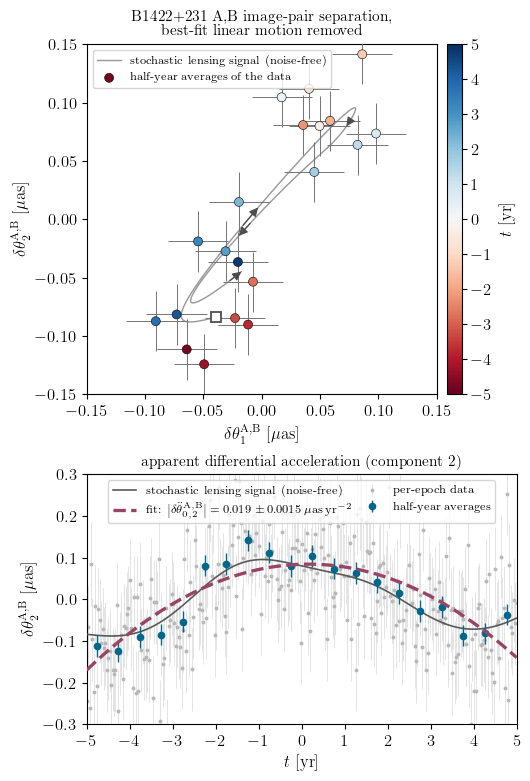

saved ../figs/concept_6.pdf
saved ../figs/concept_7.pdf


saved ../figs/concept_8.pdf
saved ../figs/concept_9.pdf


In [6]:
# diverging ramp for the time coloring, centered on the middle of the campaign: the
# epochs that anchor the acceleration fit --- the two ends of the baseline --- are the
# dark ones, the least informative mid-baseline epochs the light ones
cmap_t = plt.get_cmap('RdBu')
t_lim = tau/(2*year)   # colorbar and time axis run over the full baseline, -tau/2 .. +tau/2


def round_up(x, step):
    return step * np.ceil(x / step - 1e-9)


def make_fig(d, fname, lim_a=None, lim_b=None):
    """Two-panel concept figure for one realization; `d` comes from `build`."""
    resid, data, data_b = d['resid'], d['data'], d['data_b']
    t_b, sigma_b, c_dom, p2 = d['t_b'], d['sigma_b'], d['c_dom'], d['p2']
    # symmetric limits: the fiducial 0.15 / 0.3 muas unless a realization needs more room
    if lim_a is None:
        lim_a = max(0.15, round_up(1.05*max(np.abs(resid).max(), np.abs(data_b).max())/muas, 0.05))
    if lim_b is None:
        lim_b = max(0.30, round_up(1.15*max(np.abs(resid[c_dom]).max(),
                                            np.abs(data_b[c_dom]).max())/muas, 0.05))
    step_a = 0.05 if lim_a <= 0.25 else 0.1

    # explicit inch-based layout: the top panel is square (1:1 sky-plane scale)
    W, H = 5.2, 7.9
    fig = plt.figure(figsize=(W, H))
    left, right_pad, cbar_w, cbar_pad, cbar_lab = 0.80, 0.10, 0.15, 0.10, 0.55
    wa = W - left - right_pad - (cbar_pad + cbar_w + cbar_lab)   # square top panel
    wb = W - left - right_pad
    hb = 2.50
    y_a = (H - 0.05 - 0.45 - wa) / H                              # top panel bottom edge
    y_b = (0.05 + 0.55) / H
    axa = fig.add_axes([left/W, y_a, wa/W, wa/H])
    cax = fig.add_axes([(left + wa + cbar_pad)/W, y_a, cbar_w/W, wa/H])
    axb = fig.add_axes([left/W, y_b, wb/W, hb/H])

    # (a) sky-plane random walk of the pair separation (linear motion removed)
    axa.plot(resid[0]/muas, resid[1]/muas, color=(0.55, 0.55, 0.55), lw=1.0, alpha=0.9, zorder=2,
             label='stochastic lensing signal (noise-free)')
    # the time coloring is diverging, so both ends of the campaign are dark: mark the
    # sense of time along the noise-free track explicitly (it typically doubles back)
    trk = resid/muas
    axa.plot(trk[0, 0], trk[1, 0], marker='s', ms=7.5, mfc='white', mec=(0.30, 0.30, 0.30),
             mew=1.3, ls='none', zorder=5)
    n_trk = trk.shape[1]
    for i in (n_trk//4, n_trk//2, 3*n_trk//4, n_trk - 1):
        axa.annotate('', xy=trk[:, i], xytext=trk[:, i - 5],
                     arrowprops=dict(arrowstyle='-|>', color=(0.30, 0.30, 0.30), lw=0.9,
                                     mutation_scale=13, shrinkA=0, shrinkB=0), zorder=5)
    sc = axa.scatter(data_b[0]/muas, data_b[1]/muas, c=(t_b/year), cmap=cmap_t, s=42,
                     vmin=-t_lim, vmax=t_lim,
                     edgecolor='k', linewidths=0.4, zorder=4, label=r'half-year averages of the data')
    axa.errorbar(data_b[0]/muas, data_b[1]/muas, xerr=sigma_b/muas, yerr=sigma_b/muas,
                 fmt='none', ecolor=(0.45, 0.45, 0.45), elinewidth=0.7, zorder=3)
    cb = fig.colorbar(sc, cax=cax, ticks=np.arange(-t_lim, t_lim + 0.5))
    cb.set_label(r'$t~[\mathrm{yr}]$')
    axa.set_xlabel(r'$\delta\theta_1^\mathrm{A,B}~[\mathrm{\mu as}]$')
    axa.set_ylabel(r'$\delta\theta_2^\mathrm{A,B}~[\mathrm{\mu as}]$')
    axa.set_title('B1422$+$231 A,B image-pair separation,\nbest-fit linear motion removed', fontsize=11)
    axa.set_xlim(-lim_a, lim_a); axa.set_ylim(-lim_a, lim_a)
    axa.set_xticks(np.arange(-lim_a, lim_a + step_a/2, step_a))
    axa.set_yticks(np.arange(-lim_a, lim_a + step_a/2, step_a))
    axa.set_aspect('equal', adjustable='box')
    axa.legend(loc='upper left', fontsize=8.5)

    # (b) dominant component vs time with the quadratic (acceleration) fit
    axb.errorbar(t_obs/year, data[c_dom]/muas, yerr=sigma_delta_theta/muas, fmt='o', ms=1.8,
                 color=(0.72, 0.72, 0.72), ecolor=(0.85, 0.85, 0.85), elinewidth=0.5, zorder=1,
                 label=r'per-epoch data')
    axb.errorbar(t_b/year, data_b[c_dom]/muas, yerr=sigma_b/muas, fmt='o', ms=4.5,
                 color=colors[3], ecolor=colors[3], elinewidth=1.0, zorder=4,
                 label=r'half-year averages')
    axb.plot(t_obs/year, resid[c_dom]/muas, color=(0.35, 0.35, 0.35), lw=1.2, zorder=3,
             label='stochastic lensing signal (noise-free)')
    axb.plot(t_obs/year, np.polyval(p2, t_obs)/muas, color=colors[4], lw=2.4, ls='dashed', zorder=5,
             label=r'fit: $\big|\delta\ddot\theta_{0,%d}^{\mathrm{A,B}}\big| = %.2g \pm %.2g\,\mathrm{\mu as\,yr^{-2}}$'
                   % (c_dom+1, abs(d['acc_meas'])/muasyy, sigma_theta_ddot/muasyy))
    axb.set_xlabel(r'$t~[\mathrm{yr}]$')
    axb.set_ylabel(r'$\delta\theta_%d^\mathrm{A,B}~[\mathrm{\mu as}]$' % (c_dom+1))
    axb.set_xlim(-t_lim, t_lim)
    axb.set_xticks(np.arange(-t_lim, t_lim + 0.5))
    axb.set_ylim(-lim_b, lim_b)
    axb.set_title(r'apparent differential acceleration (component %d)' % (c_dom+1), fontsize=11)
    axb.legend(loc='upper center', fontsize=8.5, ncol=2, columnspacing=0.8)

    fig.savefig(fname, bbox_inches='tight')
    print('saved', fname)
    return fig


# all ten draws are written out; the one shown in the paper is also copied to
# concept.pdf, and is the only one whose axis limits are pinned to round values
k_paper = 5
for k, d in enumerate(runs):
    paper = (k == k_paper)
    fig = make_fig(d, '../figs/concept_%d.pdf' % k,
                   lim_a=0.15 if paper else None, lim_b=0.30 if paper else None)
    if paper:
        fig.savefig('../figs/concept.pdf', bbox_inches='tight')
        print('saved ../figs/concept.pdf  (= concept_%d.pdf, seed %d)' % (k, seeds[k]))
        plt.show()
    else:
        plt.close(fig)
